# 1. IMPORTS

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve
import joblib
import os

# 2. Loading the dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/Portfolio/61172ba1c39dc86f2c15cb80257acf06a391a6a1/diabetes.csv"
df = pd.read_csv(url)

## Preview of Data

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# 3. Initial Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Dataset Dimensions

In [5]:
print("Shape : ",df.shape)
print("Size : ",df.size)

Shape :  (768, 9)
Size :  6912


**Observation :**

- The dataset initally contains 768 observations and 9 variables.

- The BMI and DiabetesPedigreeFunction are only the variables that are Type Float64 present in the whole data.

# 4. Data Cleaning

## Check for Missing Values

In [6]:
print("No.of Null Values : \n",df.isnull().sum())

No.of Null Values : 
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Observation :**

The dataset does not contain any explicit missing (`NaN`) values. However, several medically unrealistic values of `0` are present in columns such as `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`. These zero values are treated as missing values during preprocessing.


## Check for Duplicates Records

In [7]:
print("No.of Duplicate Records : ",df.duplicated().sum())

No.of Duplicate Records :  0


**Observation :**

- The Dataset has no Duplicate Records.

# 5. Descriptive Statistical Analysis

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Observation :**

- The average outcome of Diabetes is 0.34 (34%).
- Outcome is a discrete variable contains only 0 and 1.
- The Pregnancies ranges from 0 to 17 with an average of approximately 3.8 Pregnancies.
- The Glucose levels ranges from 0 to 199 with average glucose level of 120.
- The BloodPressure ranges from 0 to 122 with average Bloodpressure level around 69.
- The Skinthickness ranges from 0 to 99 with average of 20.
- The BMI ranges from 0 to 67 with a mean of 31.
- There are some suspicious records of BMI,BloodPressure,SkinThickness recorded as 0.
- The descriptive statistics indicate potentially extreme values in variables such as Pregnancies, Insulin, and DiabetesPedigreeFunction. These are further investigated using boxplots.

# 6. Exploratory Data Analysis

In [9]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## BOXPLOT Analysis

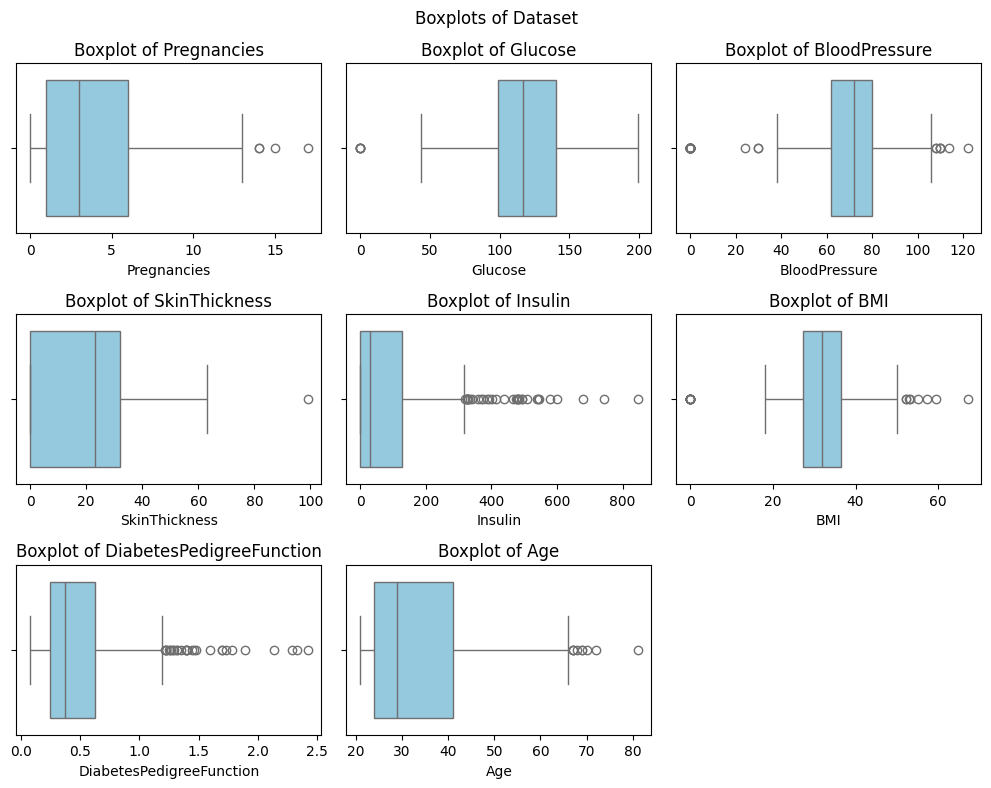

In [10]:
# Select only numeric feature columns, explicitly excluding 'Outcome'
num_cols = df.select_dtypes(include=["number"]).drop(
    columns=["Outcome"], errors="ignore"
).columns

fig, ax = plt.subplots(3, 3, figsize=(10, 8))

# Iterate through axes and column names
for axis, col in zip(ax.flat, num_cols):
    sns.boxplot(data=df, x=col, ax=axis, color="skyblue")
    axis.set_title(f"Boxplot of {col}")

# Remove empty subplots if num_cols < 9
for axis in ax.flat[len(num_cols) :]:
    axis.remove()
plt.suptitle("Boxplots of Dataset")
plt.tight_layout()
plt.show()

**Observation :**

- Insulin, DiabetesPedigreeFunction, and BMI show a relatively higher number of potential outliers compared with the other variables.
- Pregnancies, Glucose, BloodPressure, and SkinThickness show comparatively fewer potential outliers.

## HISTOGRAM Analysis

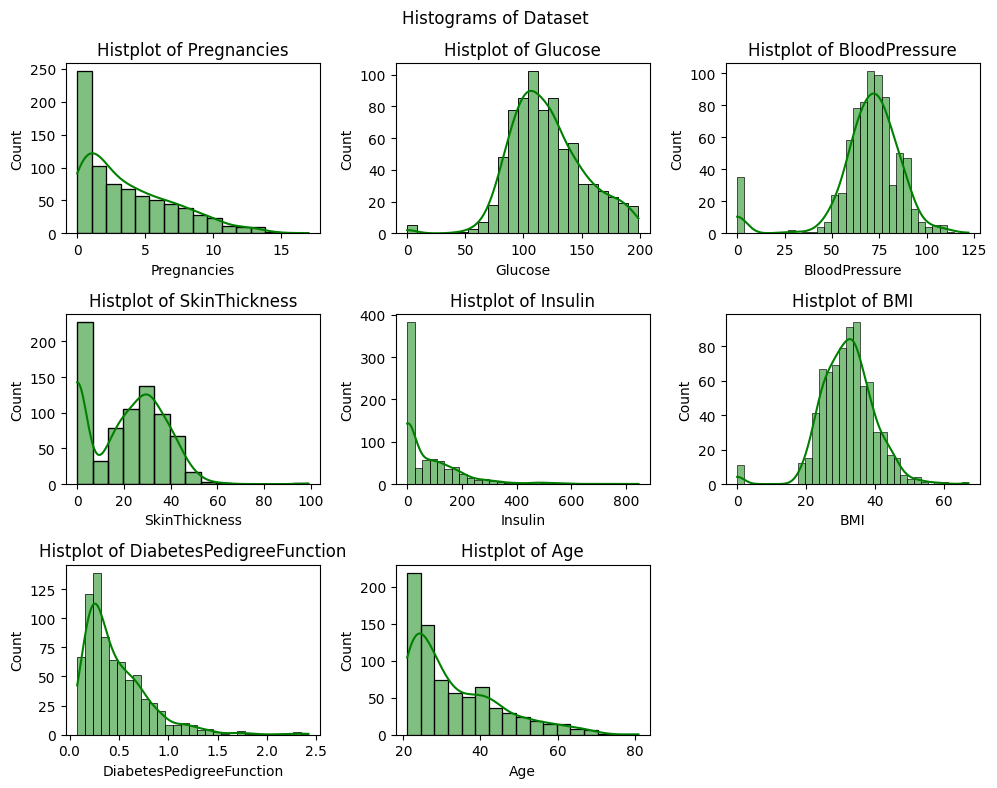

In [11]:

fig, ax = plt.subplots(3, 3, figsize=(10, 8))

# Iterate through axes and column names
for axis, col in zip(ax.flat, num_cols):
    sns.histplot(data=df, x=col, ax=axis, color="g",kde=True,edgecolor="black")
    axis.set_title(f"Histplot of {col}")

# Remove empty subplots if num_cols < 9
for axis in ax.flat[len(num_cols) :]:
    axis.remove()

plt.suptitle("Histograms of Dataset")
plt.tight_layout()
plt.show()

**Observation :**

Pregnancies, Insulin, and Age appear to be right-skewed. The distributions of SkinThickness and BMI contain noticeable concentrations near zero, which may be influenced by invalid zero values representing missing data. Therefore, these distributions should be interpreted cautiously before preprocessing.

## COUNTPLOT Analysis

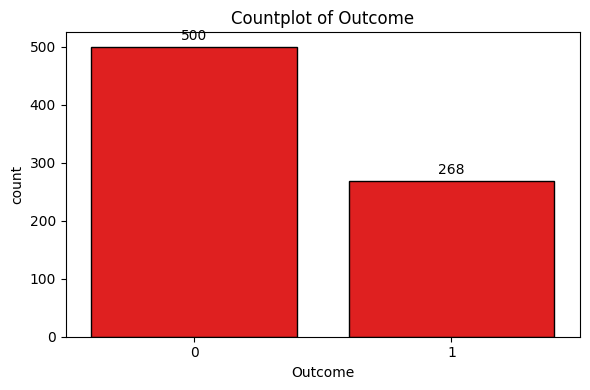

Outcome 0 : 65.10416666666666
Outcome 1 : 34.89583333333333


In [12]:

plt.figure(figsize=(6,4))

c_col = df["Outcome"]

ax = sns.countplot(data=df,x=c_col,edgecolor="black",color="red")
plt.title("Countplot of Outcome")
plt.xlabel("Outcome")

for container in ax.containers:
  ax.bar_label(container,padding=3)

plt.tight_layout()
plt.show()

count_0 = (df["Outcome"]==0).sum()
count_1 = (df["Outcome"]==1).sum()

print("Outcome 0 :", (count_0/len(df))*100)
print("Outcome 1 :", (count_1/len(df))*100)


**Observation:**

* Most records belong to Outcome = 0, indicating that those individuals do not have diabetes.
* Approximately 65% of the records belong to the non-diabetic class, while approximately 35% belong to the diabetic class.
* The dataset shows a moderate class imbalance, but both classes are sufficiently represented for classification modeling.


## CORRELATION ANALYSIS

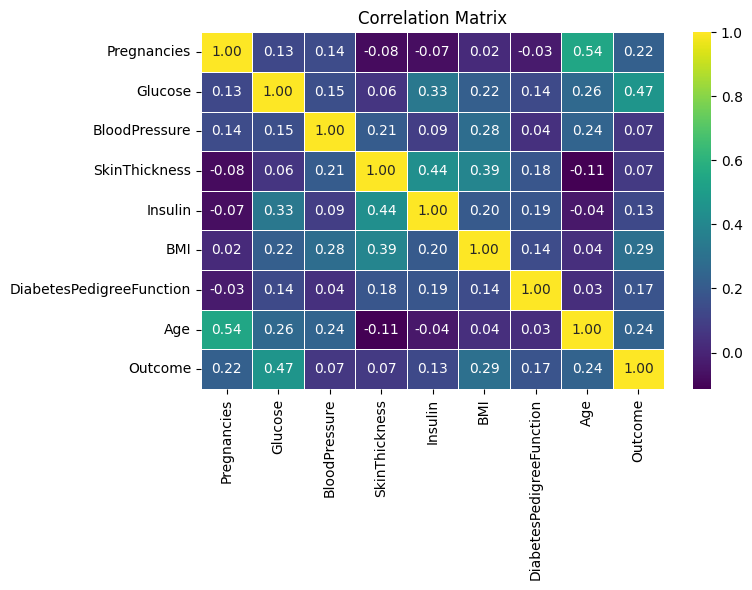

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,fmt=".2f",linewidths=0.5,cmap='viridis')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:**

* Pregnancies and Age show a positive correlation.
* Glucose has one of the strongest positive correlations with Outcome, indicating that higher glucose levels are associated with a higher likelihood of diabetes.
* BMI and Age also show positive relationships with Outcome.
* SkinThickness and Insulin show some correlation with other health-related variables.
* DiabetesPedigreeFunction has relatively low correlation with most variables; however, low correlation alone does not mean that the feature is unimportant. Its usefulness should be evaluated through model performance and feature analysis.

# 7. Data Preprocessing

## Replacing Variables with abnormal Records with np.nan

In [14]:
print("No.of 0's in BMI :",(df["BMI"]==0).sum())
print("No.of 0's in Glucose :",(df["Glucose"]==0).sum())
print("No.of 0's in Blood Pressure :",(df["BloodPressure"]==0).sum())
print("No.of 0's in Insulin :",(df["Insulin"]==0).sum())
print("No.of 0's in Skin Thickness :",(df["SkinThickness"]==0).sum())


No.of 0's in BMI : 11
No.of 0's in Glucose : 5
No.of 0's in Blood Pressure : 35
No.of 0's in Insulin : 374
No.of 0's in Skin Thickness : 227


**Observation:**

Values of 0 in BMI, Glucose, BloodPressure, SkinThickness, and Insulin are considered physiologically unrealistic or invalid for this dataset. Therefore, these values are treated as missing values before training the machine learning model, as retaining them could negatively affect model performance.

In [15]:
cols_with_zeroes = ["BMI","Glucose","BloodPressure","Insulin","SkinThickness"]
df[cols_with_zeroes] = df[cols_with_zeroes].replace(0,np.nan)

## Checking Missing Values and percentages

In [16]:
print("No.of Null Values : \n\n",df.isnull().sum())

No.of Null Values : 

 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [17]:
missing_percentage = (df.isnull().sum()/len(df))*100
print("Missing Percentage :\n",missing_percentage.sort_values(ascending=False))

Missing Percentage :
 Insulin                     48.697917
SkinThickness               29.557292
BloodPressure                4.557292
BMI                          1.432292
Glucose                      0.651042
Pregnancies                  0.000000
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64


**Observation :**

- Insulin contains approximately 49% missing values, which is a substantial proportion.
- SkinThickness contains approximately 30% missing values.
- BloodPressure contains approximately 5% missing values.
- BMI and Glucose contain relatively small percentages of missing values.

Median imputation is applied after the train-test split to prevent data leakage.

## Feature and Target Seperation

In [18]:
X = df.drop(columns = ["Outcome"])
y = df["Outcome"]

print("X Shape : ",X.shape)
print("y Shape : ",y.shape)

X Shape :  (768, 8)
y Shape :  (768,)


## Train-Test Split

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 42,stratify =y)

print("X_train Shape : ",X_train.shape)
print("X_test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)

X_train Shape :  (614, 8)
X_test Shape :  (154, 8)
y_train Shape :  (614,)
y_test Shape :  (154,)


## Handling Missing Values

Filling Missing values with Median

In [20]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)

## Encoding Categorical Variables

As there are no Categorical Variables in data. We don't need to perform Encoding Categorical Variables.

# 8. LOGISTIC REGRESSION

## Feature Scaling

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

## Model Training

In [22]:
model = LogisticRegression(max_iter = 1000)

model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

## Prediction

In [23]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

comparision = pd.DataFrame({"Actual Outcome":y_test,"Predicted Outcome":y_pred})

print(comparision["Actual Outcome"].value_counts())
print("="*50)
print(comparision["Predicted Outcome"].value_counts())



Actual Outcome
0    100
1     54
Name: count, dtype: int64
Predicted Outcome
0    109
1     45
Name: count, dtype: int64


## Evaluation Metrics

In [24]:
Accuracy = accuracy_score(y_test,y_pred)
Precision = precision_score(y_test,y_pred)
Recall = recall_score(y_test,y_pred)
F1 = f1_score(y_test,y_pred)
ROC_AUC = roc_auc_score(y_test,y_prob)

Evaluation_Summary = pd.DataFrame({"Accuracy":[Accuracy],"Precision":[Precision],"Recall":[Recall],"F1":[F1],"ROC-AUC":[ROC_AUC]})
print(Evaluation_Summary)

   Accuracy  Precision  Recall        F1   ROC-AUC
0  0.707792        0.6     0.5  0.545455  0.812963


## Classification Report

In [25]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## Confusion Matrix

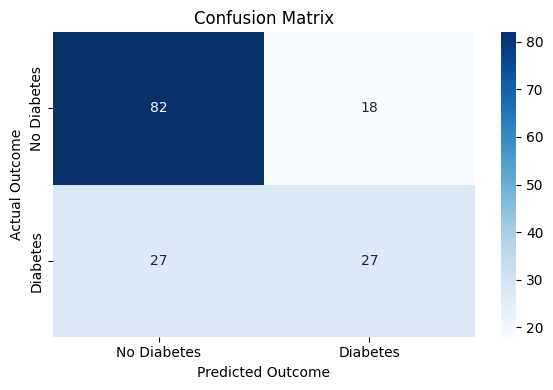

In [26]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize = (6,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Diabetes","Diabetes"],yticklabels=["No Diabetes","Diabetes"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()
plt.show()

## ROC - AUC Curve

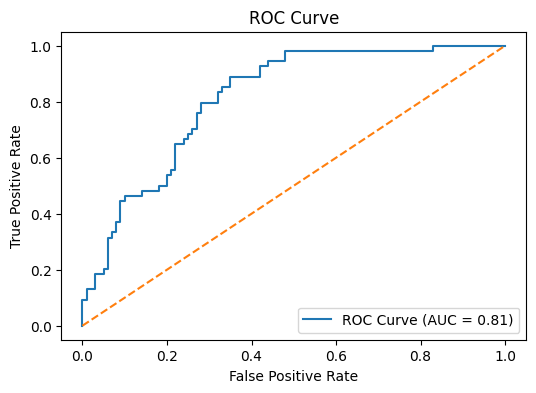

In [27]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {ROC_AUC:.2f})")
plt.plot([0,1],[0,1],linestyle = "--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

## Feature Coefficient Analysis

In [28]:
# Create a DataFrame containing feature coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance


,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.182567,1.182567
5,BMI,0.688652,0.688652
0,Pregnancies,0.377446,0.377446
6,DiabetesPedigreeFunction,0.233337,0.233337
7,Age,0.147794,0.147794
4,Insulin,-0.066119,0.066119
2,BloodPressure,-0.044111,0.044111
3,SkinThickness,0.028321,0.028321


**Observation:**

The Logistic Regression coefficient analysis shows that Glucose has the strongest positive association with the model's predicted probability of diabetes, followed by BMI and Pregnancies. DiabetesPedigreeFunction and Age also contribute positively to the prediction.

Insulin and BloodPressure have very small negative coefficients, while SkinThickness has the smallest coefficient magnitude. Overall, Glucose and BMI appear to be the most influential features in this Logistic Regression model.

These coefficients represent associations learned by the model and should not be interpreted as evidence of causation.

## Coefficient Visualization

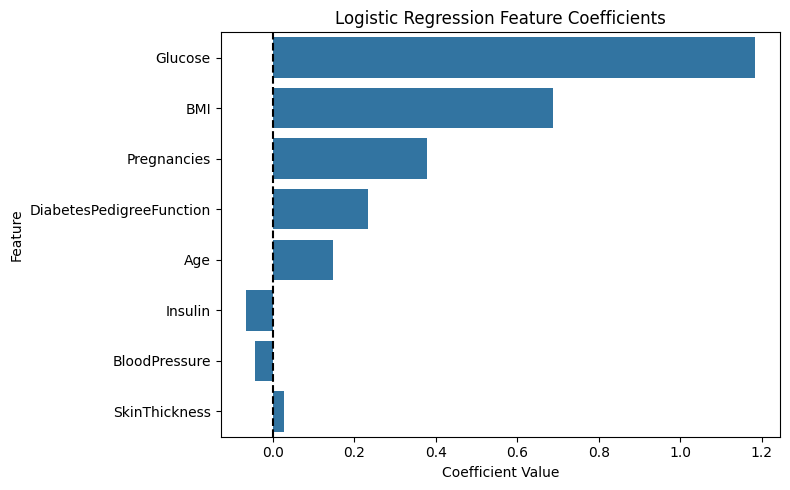

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.axvline(x=0, color="black", linestyle="--")

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Saving the Model

In [31]:
# Save the trained Logistic Regression model
joblib.dump(model, "logistic_regression_model.pkl")

# Save the median imputer
joblib.dump(imputer, "imputer.pkl")

# Save the StandardScaler
joblib.dump(scaler, "scaler.pkl")

print("Model and preprocessing files saved successfully!")

Model and preprocessing files saved successfully!


In [32]:
import os

print(os.listdir())

['.config', 'logistic_regression_model.pkl', 'scaler.pkl', 'imputer.pkl', 'sample_data']


# CONCLUSION

A Logistic Regression model was developed to predict diabetes using clinical and demographic variables. During preprocessing, physiologically unrealistic zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI were treated as missing values. Median imputation was performed after the train-test split to prevent data leakage, and feature scaling was applied before training the Logistic Regression model.

The model achieved an accuracy of approximately 70.78% and an ROC-AUC score of approximately 0.81, indicating good discriminative ability between diabetic and non-diabetic cases. Glucose and BMI were identified as the most influential features based on the model coefficients.

However, the recall for the diabetic class was 50%, indicating that the model failed to identify a considerable number of actual diabetic cases. Therefore, although the model demonstrates reasonable overall predictive performance, further improvements could focus on improving the detection of diabetic cases.

# INTERVIEW QUESTIONS

## 1. What is the difference between precision and recall?

Precision measures how many of the positively predicted instances were actually correct, focusing on minimizing false positives. Recall measures how many of the actual positive cases were correctly identified, focusing on minimizing false negatives.

## 2. What is cross-validation and why is it important in binary classification?

Cross-validation is a resampling procedure used to evaluate machine learning models on limited data samples by partitioning the dataset into $K$ subsets (folds). The model is trained on $K-1$ folds and tested on the remaining fold, repeating this process $K$ times so that every data point serves as both training and testing data.In binary classification, techniques like Stratified K-Fold Cross-Validation ensure each fold maintains the same percentage of binary samples (e.g., positive vs. negative classes) as the complete dataset.